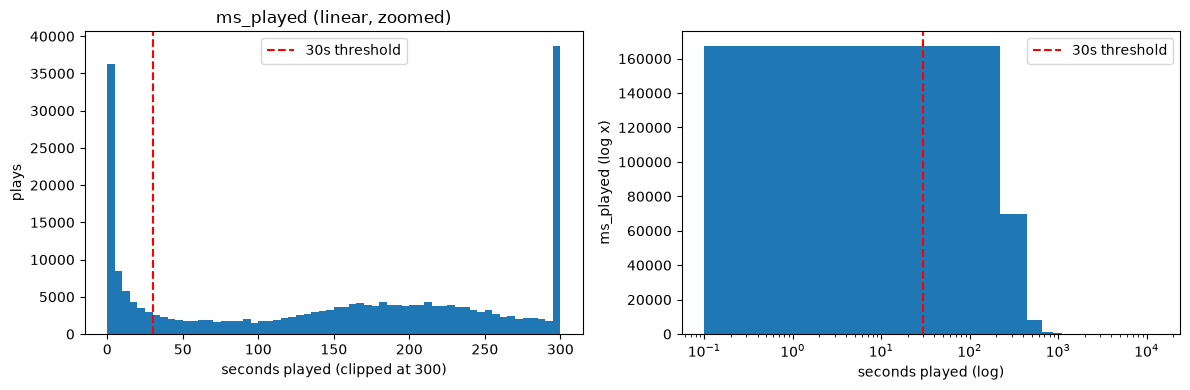

In [2]:
import matplotlib.pyplot as plt
from alys import config
from pathlib import Path
import pandas as pd

# work from phase 1 output. Fall back to the committed sample
# so that the notebook still runs on a fresh clone that hasn't
# built the private data

interim = config.INTERIM_DIR / "plays.parquet"
sample = config.SAMPLE_DIR / "plays_sample.parquet"
path = interim if interim.exists() else sample

plays = pd.read_parquet(path)

threshold_ms = config.MIN_LISTEN_MS  # 30,000

# ms_played is very right-skewed, i.e. very few long plays
# So: look at it in 2 ways: (1) raw seconds (zoomed to first few min)
# and (2) log-scale for a long tail
seconds = plays["ms_played"] / 1000

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12, 4))

# linear view, zoomed to 0-300 s where the "did I listen" data sits
ax_lin.hist(seconds.clip(upper=300), bins=60)
ax_lin.axvline(threshold_ms / 1000, color="red", linestyle="--", label="30s threshold")
ax_lin.set_xlabel("seconds played (clipped at 300)")
ax_lin.set_ylabel("plays")
ax_lin.set_title("ms_played (linear, zoomed)")
ax_lin.legend()

# log view to see the whole tale
# this way the near-zero spike doesn't swamp it
ax_log.hist(seconds.clip(lower=0.1), bins=60)
ax_log.set_xscale("log")
ax_log.axvline(threshold_ms / 1000, color="red", linestyle="--", label="30s threshold")
ax_log.set_xlabel("seconds played (log)")
ax_log.set_ylabel("ms_played (log x)")
ax_log.legend()

fig.tight_layout()
plt.show()

In [3]:
below = (plays["ms_played"] < threshold_ms).mean()
print(f"{below:.1%} of plays fall below the 30s threshold")
print(plays["ms_played"].div(1000).describe()) # summary stats, in seconds

24.8% of plays fall below the 30s threshold
count    247691.000000
mean        171.275713
std         164.087375
min           0.000000
25%          31.038000
50%         165.250000
75%         245.680500
max       13209.999000
Name: ms_played, dtype: float64


`ms_played` is bimodal: a large spike of sub-5 s plays (skips) and a hump of full-length song plays, separated by a low-density valley. 30s threshold sits in that valley, & so separates skips from real listens (24.8% below); its exact position is not sensitive.

In [5]:
figpath = config.PROJECT_ROOT / "reports" / "figures" / "2026_08_05_ms_played_distribution.png"
figpath.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("saved", figpath)

saved /Users/michael/code/mr/alys/reports/figures/2026_08_05_ms_played_distribution.png
